## statistical analysis

throughspecify the fields for statistical analysis，obtain each featurep_value，allp_valuecomputeallisbaseatTtestcompute。supports different grouping specifications`group`，e.g.,train、val、testand other group statistics。

for the two major categoriesfeature

1. discrete feature，count and proportion。
2. continuous feature，statisticsmean、variance。

In [1]:
import pandas as pd
import numpy as np
from onekey_algo import OnekeyDS as okds
from onekey_algo import get_param_in_cwd
from onekey_algo.custom.utils import print_join_info

task = get_param_in_cwd('task_column') or 'label'
p_value = get_param_in_cwd('p_value') or 0.05
# change to your own clinical data file。
test_data = pd.read_csv(get_param_in_cwd('clinic_file') or okds.survival)
stats_columns_settings = get_param_in_cwd('stats_columns')
continuous_columns_settings = get_param_in_cwd('continuous_columns')
mapping_columns_settings = get_param_in_cwd('mapping_columns')
test_data = test_data[[c for c in test_data.columns if c != task]]
test_data['ID'] = test_data['ID'].map(lambda x: f"{x}.nii.gz" if not (f"{x}".endswith('.nii.gz') or  f"{x}".endswith('.nii')) else x)
group_info = pd.read_csv(get_param_in_cwd('label_file'))
print_join_info(test_data, group_info)
test_data = pd.merge(test_data, group_info, on='ID', how='inner')
test_data

[2026-07-14 19:05:23 - <frozen onekey_algo.custom.utils>:  60]	INFO	IDfeature完全match！


,ID,Hashimotodisease,FT3,FT4,TSH,TgAb,TPOAb,Tg,gender,age,label,group
0,1.nii.gz,0,5.22,15.80,1.62,0.0,0.0,13.74,0,45,1,train
1,2.nii.gz,0,5.06,15.43,0.95,17.5,30.9,17.68,0,34,1,train
2,3.nii.gz,1,6.18,20.51,2.09,1000.0,1000.0,0.20,1,24,1,train
3,4.nii.gz,0,5.36,16.17,0.36,0.0,35.3,15.40,1,39,1,train
4,5.nii.gz,0,4.30,18.42,0.83,0.0,34.7,44.17,0,42,1,test
...,...,...,...,...,...,...,...,...,...,...,...,...
114,115.nii.gz,0,5.50,18.26,1.61,20.6,0.0,21.63,0,38,0,test
115,116.nii.gz,0,5.33,16.37,1.90,18.0,0.0,17.55,0,61,0,train
116,117.nii.gz,1,6.24,14.65,1.03,1000.0,0.0,0.40,0,61,0,test
117,118.nii.gz,1,5.51,15.59,5.92,1000.0,1000.0,0.10,0,33,0,train


# featureNameprocessing

removeremoveallfeatureNameinspecial character。

In [2]:
import re

def map_cnames(x):
    x = re.split('[（|(]', x)[0]
    x = x.replace('-', '_').replace(' ', '_').replace('>', '').replace('/', '_')
    return x.strip()

test_data.columns = list(map(map_cnames, test_data.columns))
test_data.columns

Index(['ID', 'Hashimotodisease', 'FT3', 'FT4', 'TSH', 'TgAb', 'TPOAb', 'Tg',
       'gender', 'age', 'label', 'group'],
      dtype='object')

# analyze the data

obtain features to analyzefeatureColumnname，if not specified，auto detect。

In [3]:
stats_columns = stats_columns_settings or list(test_data.columns[1:-2])
test_data = test_data.copy()[['ID'] + stats_columns + ['group', 'label']]
test_data

,ID,Hashimotodisease,FT3,FT4,TSH,TgAb,TPOAb,Tg,gender,age,group,label
0,1.nii.gz,0,5.22,15.80,1.62,0.0,0.0,13.74,0,45,train,1
1,2.nii.gz,0,5.06,15.43,0.95,17.5,30.9,17.68,0,34,train,1
2,3.nii.gz,1,6.18,20.51,2.09,1000.0,1000.0,0.20,1,24,train,1
3,4.nii.gz,0,5.36,16.17,0.36,0.0,35.3,15.40,1,39,train,1
4,5.nii.gz,0,4.30,18.42,0.83,0.0,34.7,44.17,0,42,test,1
...,...,...,...,...,...,...,...,...,...,...,...,...
114,115.nii.gz,0,5.50,18.26,1.61,20.6,0.0,21.63,0,38,test,0
115,116.nii.gz,0,5.33,16.37,1.90,18.0,0.0,17.55,0,61,train,0
116,117.nii.gz,1,6.24,14.65,1.03,1000.0,0.0,0.40,0,61,test,0
117,118.nii.gz,1,5.51,15.59,5.92,1000.0,1000.0,0.10,0,33,train,0


# feature listColumnmapping

all features needing mappingColumn，rangenot specified，canperform auto judgement。

In [4]:
mapping_columns = mapping_columns_settings or [c for c in test_data.columns[1:-2] if test_data[c].dtype == object]
mapping_columns

[]

# data mapping

for all non-numeric data，canperformCategorymapping。

In [5]:
from onekey_algo.custom.utils import map2numerical

data, mapping = map2numerical(test_data, mapping_columns=mapping_columns)
mapping

{}

In [6]:
from onekey_algo.custom.components.comp1 import fillna

data = fillna(data, fill_mod='50%')
continuous_columns = []
for col in test_data.columns:
    if test_data[col].apply(lambda x: x.is_integer() if isinstance(x, float) else False).all():
        test_data[col] = test_data[col].astype(int)

for c in stats_columns:
#     print(c, np.unique(test_data[c]), test_data[c].dtype)
    if len(np.unique(test_data[c])) > 5 or not np.int8 <= test_data[c].dtype <= np.int64:
        continuous_columns.append(c)
        
continuous_columns = continuous_columns_settings or continuous_columns
continuous_columns = [c for c in continuous_columns if c not in ('differentation')]
continuous_columns

['FT3', 'FT4', 'TSH', 'TgAb', 'TPOAb', 'Tg', 'age']

# missing value imputation

In [7]:
import os
os.makedirs('data', exist_ok=True)
data.to_csv('data/clinical.csv', index=False)
data

,ID,Hashimotodisease,FT3,FT4,TSH,TgAb,TPOAb,Tg,gender,age,group,label
0,1.nii.gz,0,5.22,15.80,1.62,0.0,0.0,13.74,0,45,train,1
1,2.nii.gz,0,5.06,15.43,0.95,17.5,30.9,17.68,0,34,train,1
2,3.nii.gz,1,6.18,20.51,2.09,1000.0,1000.0,0.20,1,24,train,1
3,4.nii.gz,0,5.36,16.17,0.36,0.0,35.3,15.40,1,39,train,1
4,5.nii.gz,0,4.30,18.42,0.83,0.0,34.7,44.17,0,42,test,1
...,...,...,...,...,...,...,...,...,...,...,...,...
114,115.nii.gz,0,5.50,18.26,1.61,20.6,0.0,21.63,0,38,test,0
115,116.nii.gz,0,5.33,16.37,1.90,18.0,0.0,17.55,0,61,train,0
116,117.nii.gz,1,6.24,14.65,1.03,1000.0,0.0,0.40,0,61,test,0
117,118.nii.gz,1,5.51,15.59,5.92,1000.0,1000.0,0.10,0,33,train,0


### statistical analysis

supports two data formats，respectively correspond to`pretty`parameter`True`and`False`, When`True`time，outputistable mode，otherwiseofthenisdictdata。

```python
def clinic_stats(data: DataFrame, stats_columns: Union[str, List[str]], label_column='label',
                 group_column: str = None, continuous_columns: Union[str, List[str]] = None,
                 pretty: bool = True) -> Union[dict, DataFrame]:
    """

    Args:
        data: data
        stats_columns: need to be countedColumnname
        label_column: binary classificationlabelColumn，default`label`
        group_column: grouping basis for statistics，e.g., distinguish training set、test set、validation set。
        continuous_columns: thatsomeColumniscontinuous variable，continuous variable statisticsmeanvariance。
        pretty: bool, iswhether to beautify the output format。

    Returns:
        stats DataFrame or json

    """
```

In [8]:
from onekey_algo.custom.components.stats import clinic_stats

pd.set_option('display.max_rows', None)
stats = clinic_stats(data, 
                     stats_columns= stats_columns,
                     label_column=task, 
                     group_column='group', 
                     continuous_columns= continuous_columns, 
                     pretty=True, verbose=False)
stats.to_csv('stats.csv', index=False, encoding='utf_8_sig')
stats

,feature_name,train-label=ALL,train-label=0,train-label=1,pvalue,test-label=ALL,test-label=0,test-label=1,pvalue
0,FT3,5.38±0.60,5.26±0.67,5.45±0.54,0.191,5.32±0.61,5.30±0.64,5.34±0.60,0.825
1,FT4,16.07±2.44,16.38±2.35,15.86±2.50,0.306,16.24±2.58,15.95±2.03,16.48±2.99,0.619
2,TSH,1.74±0.95,1.81±1.06,1.70±0.87,0.764,2.02±1.30,1.81±0.89,2.19±1.56,0.469
3,TgAb,123.90±298.26,93.95±260.86,143.40±321.77,0.367,119.96±280.16,86.43±217.93,148.33±325.33,0.614
4,TPOAb,106.24±281.37,121.55±311.70,96.27±263.12,0.978,160.11±352.77,143.52±348.68,174.15±362.47,0.367
5,Tg,30.81±77.65,31.48±76.93,30.37±79.02,0.4,14.42±15.47,13.30±14.01,15.37±16.83,0.877
6,age,43.82±12.68,49.64±10.68,40.02±12.55,0.001,45.56±12.56,51.64±10.42,40.42±12.06,0.001
0,Hashimotodisease,,,,1.0,,,,1.0
1,0,55(77.46),22(78.57),33(76.74),,32(66.67),15(68.18),17(65.38),
2,1,16(22.54),6(21.43),10(23.26),,16(33.33),7(31.82),9(34.62),


In [9]:
sel_idx = [True if (isinstance(pv[0], str) and pv[0] != '') or (isinstance(pv[0], float) and pv[0] < p_value) else False 
           for pv in np.array(stats['pvalue'])]
sel_data = data[['ID'] + list(stats[sel_idx]['feature_name']) + ['group', 'label']]
sel_data.to_csv('clinic_sel.csv', index=False)
sel_data

,ID,age,group,label
0,1.nii.gz,45,train,1
1,2.nii.gz,34,train,1
2,3.nii.gz,24,train,1
3,4.nii.gz,39,train,1
4,5.nii.gz,42,test,1
5,6.nii.gz,39,test,1
6,7.nii.gz,27,test,1
7,8.nii.gz,39,train,1
8,9.nii.gz,38,test,1
9,10.nii.gz,38,test,1


# univariable and multivariable analysis

univariable，stepwise multivariable analysis
```python
def uni_multi_variable_analysis(data: pd.DataFrame, features: Union[str, List[str]] = None, label_column: str = 'label',
                                need_norm: Union[bool, List[bool]] = False, alpha=0.1,
                                p_value4multi: float = 0.05, save_dir: Union[str] = None, prefix: str = '',
                                **kwargs):
    """
    univariable，stepwise multivariable analysis，usep_value4multiparameter specifying the multivariable analysis threshold
    Args:
        data: data
        features: need to be analyzedfeature, defaultdivideIDandlabel_columnColumn，otherfeatureperform analysis on all。
        label_column: targetColumn
        need_norm: iswhether to standardize all analysis data, Default is False
        alpha: CI alpha, alpha/2 %；Default is 0.1i.e.95% CI
        p_value4multi: parameter specifying the multivariable analysis threshold，Default is 0.05
        save_dir: save location
        prefix: Prefix
        **kwargs:

    Returns:

    """
 ```

,Log(OR),lower 95%CI,upper 95%CI,OR,OR lower 95%CI,OR upper 95%CI,p_value
feature_name,,,,,,,
Hashimotodisease,0.511,-0.339,1.360,1.667,0.712,3.896,0.323
FT3,0.085,0.011,0.160,1.089,1.011,1.174,0.058
FT4,0.024,-0.000,0.049,1.024,1.000,1.050,0.105
TSH,0.164,-0.040,0.368,1.178,0.961,1.445,0.185
TgAb,0.001,-0.000,0.002,1.001,1.000,1.002,0.211
TPOAb,0.000,-0.001,0.002,1.000,0.999,1.002,0.770
Tg,0.002,-0.003,0.007,1.002,0.997,1.007,0.554
gender,1.153,0.382,1.923,3.167,1.465,6.841,0.014
age,0.004,-0.004,0.013,1.005,0.996,1.013,0.390


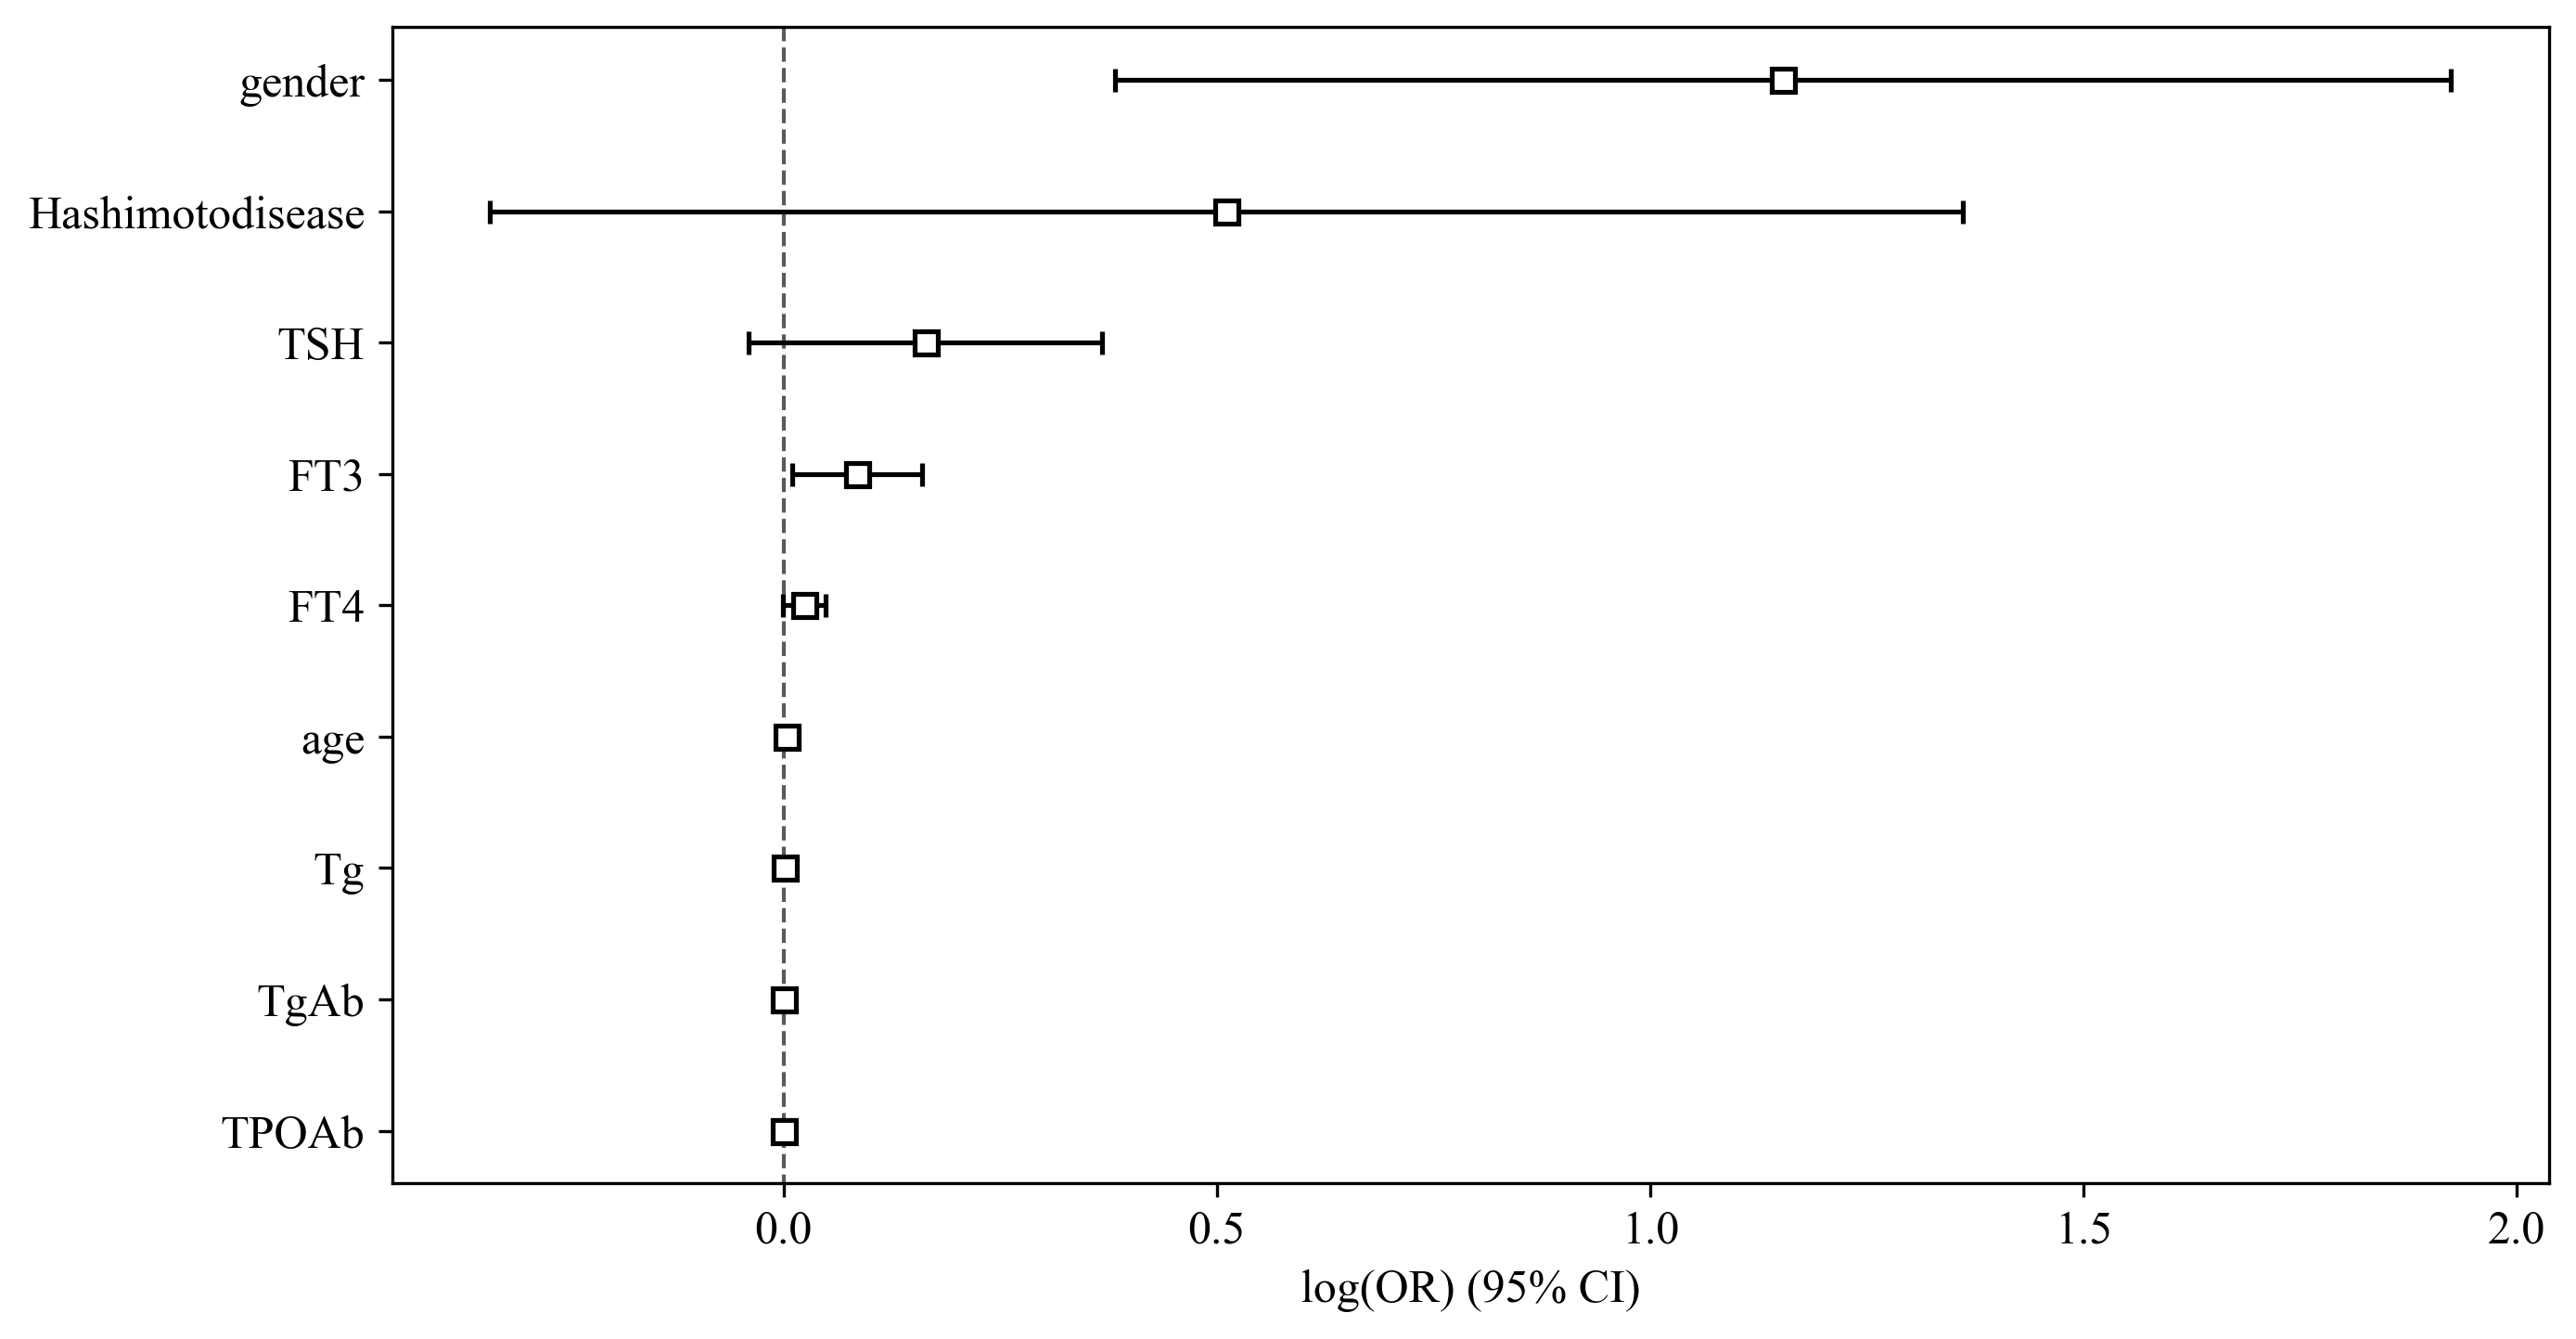

Optimization terminated successfully.
         Current function value: 0.643124
         Iterations 5


,Log(OR),lower 95%CI,upper 95%CI,OR,OR lower 95%CI,OR upper 95%CI,p_value
feature_name,,,,,,,
gender,1.153,0.382,1.923,3.167,1.465,6.841,0.014


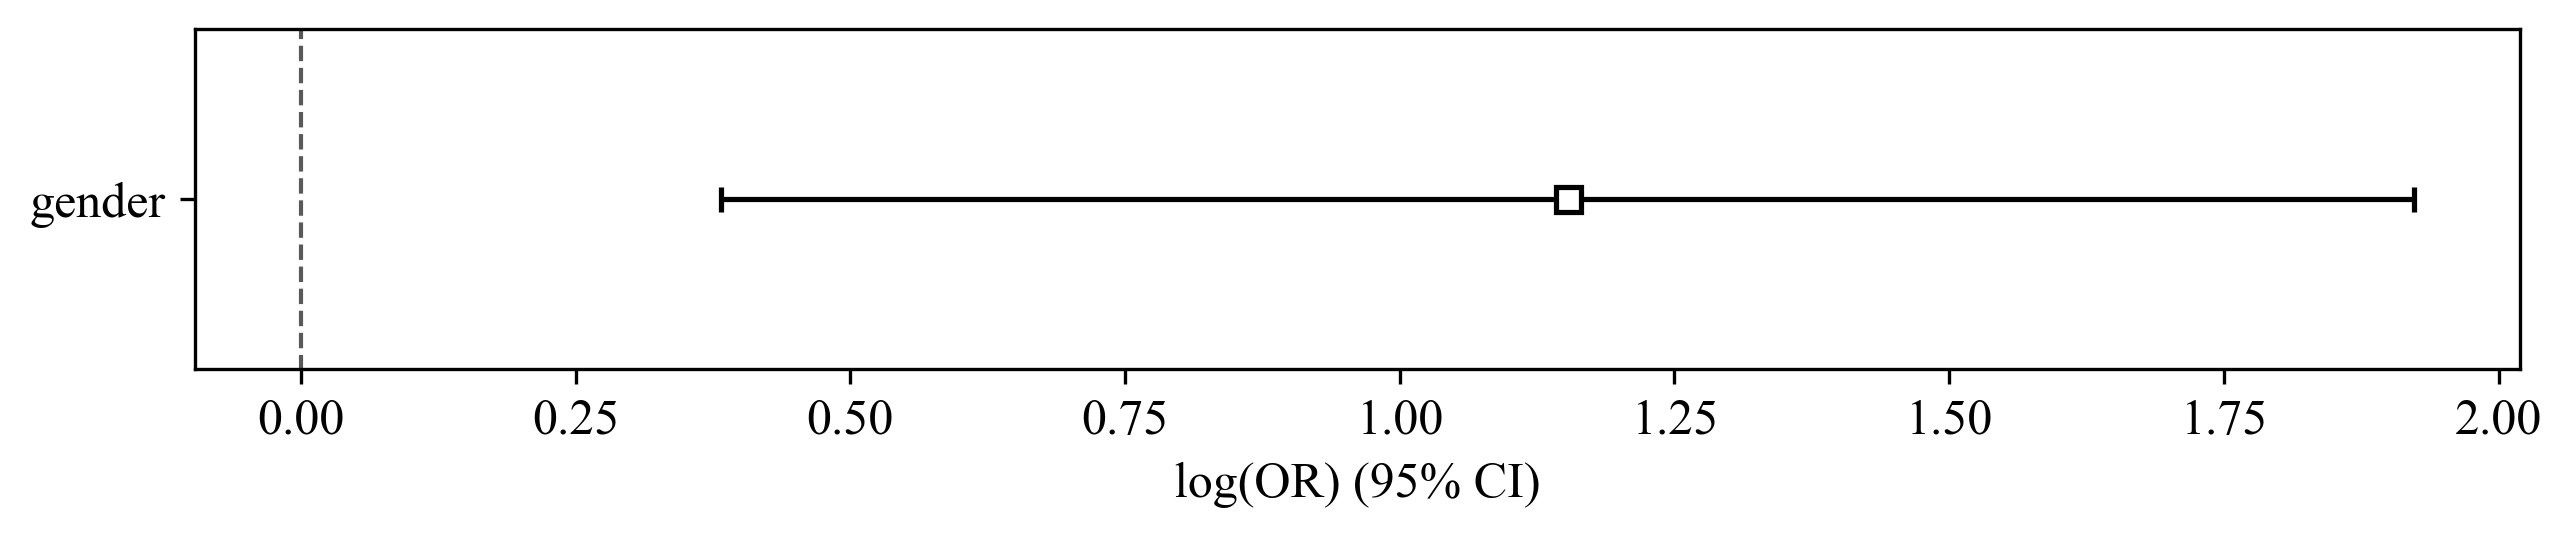

In [10]:
from onekey_algo.custom.components.comp1 import uni_multi_variable_analysis                        

uni_multi_variable_analysis(data[data['group'] == 'train'], stats_columns, save_dir='img', p_value4multi=p_value, algo='logit')

In [11]:
uni_v = pd.read_csv('img/multivariable_reg.csv')
uni_v = uni_v[uni_v['p_value'] <= p_value]
sel_data = data[['ID'] + list(uni_v['feature_name']) + ['group', 'label']]
sel_data.to_csv('clinic_sel.csv', index=False)
sel_data

,ID,gender,group,label
0,1.nii.gz,0,train,1
1,2.nii.gz,0,train,1
2,3.nii.gz,1,train,1
3,4.nii.gz,1,train,1
4,5.nii.gz,0,test,1
5,6.nii.gz,0,test,1
6,7.nii.gz,0,test,1
7,8.nii.gz,0,train,1
8,9.nii.gz,1,test,1
9,10.nii.gz,1,test,1


In [12]:
uni = pd.read_csv('img/univariable_reg.csv')
uni = uni[[c for c in uni if ('OR' in c and 'Log' not in c) or c in ['feature_name', 'p_value']]]
multi = pd.read_csv('img/multivariable_reg.csv')
multi = multi[[c for c in uni if ('OR' in c and 'Log' not in c) or c in ['feature_name', 'p_value']]]
pd.merge(uni, multi,
         on='feature_name', how='left', suffixes=['_UNI', '_MULTI']).applymap(lambda x: '' if pd.isna(x) else x)

,feature_name,OR_UNI,OR lower 95%CI_UNI,OR upper 95%CI_UNI,p_value_UNI,OR_MULTI,OR lower 95%CI_MULTI,OR upper 95%CI_MULTI,p_value_MULTI
0,TPOAb,1.000,0.999,1.002,0.770,,,,
1,TgAb,1.001,1.000,1.002,0.211,,,,
2,Tg,1.002,0.997,1.007,0.554,,,,
3,age,1.005,0.996,1.013,0.390,,,,
4,FT4,1.024,1.000,1.050,0.105,,,,
5,FT3,1.089,1.011,1.174,0.058,,,,
6,TSH,1.178,0.961,1.445,0.185,,,,
7,Hashimotodisease,1.667,0.712,3.896,0.323,,,,
8,gender,3.167,1.465,6.841,0.014,3.167,1.465,6.841,0.014
